In [1]:
#the threshold is commented

#The folder structure has been changed and the code is updated accordingly. Copy-paste the imports code block in other relevant codes if needed.

#color bar updated and y-axis is set to altitude instead of height levels in Curtains
#mass-weighted random sampling and weighted R2
#new Dataset
#update output folder if required
#Opt for m_rsg or m_sg depending on the problem at hand

output_folder_name = '4-8-2026_data-init-with-SA_global_paper_total_R2_4_parameters'
# Dendrogram_output_file_name = 'Dendrogram_ql_by_(ql+qi)_using_4_parameters.png' #write .png
# HC_output_file_name = 'HC_ql_by_(ql+qi)_using_4_parameters.csv' #write .csv
pred_vs_actual_output_file_name = 'Pred_vs_Actual_ql_by_(ql+qi)_using_4_parameters.png' #write .png

import time
overall_start_time = time.time()
import os
import importlib
import sys

# #Remove cached modules
# for module_name in list(sys.modules.keys()):
#     if 'dataset_init' in module_name:
#         del sys.modules[module_name]

# #Reimport
# from Tools import dataset_init

#To go up one level from 'Codes' sub-folder to 'MS' Folder, then the other sub-folders such as 'File_management' are accessible
MS_PATH = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(MS_PATH)

import numpy as np
import pandas as pd
#%matplotlib inline  #won't work for .py
import matplotlib.pyplot as plt
import xarray as xr

from File_management import json_file_editer as JFE
from Calculation import job_manager 
# from Tools import dataset_init
from Tools import data_init_with_SA as dataset_init
from Tools import thermodynamics
from Log_management import Log

import xgboost as xgb
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from xgboost import plot_importance

import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score

#random forest
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')

#ISLP
from matplotlib.pyplot import subplots
from statsmodels.datasets import get_rdataset
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
# from ISLP.models import ModelSpec as MS

from sklearn.tree import (DecisionTreeClassifier as DTC,
 DecisionTreeRegressor as DTR,
 plot_tree,
 export_text)
from sklearn.metrics import (accuracy_score,
 log_loss)
from sklearn.ensemble import \
 (RandomForestRegressor as RF,
 GradientBoostingRegressor as GBR)
from ISLP.bart import BART
import joblib

import csv
from Tools.data_init_with_SA import saturation_adjustment_newton

#################################################################
# Log.init_log(os.path.join('./output'), filename=f"Log_ML.txt")
Log.init_log(os.path.join(MS_PATH, 'output'), filename="Log_ML.txt")
Log.add_to_log("Log nicely initialized ")

# options_json=JFE.get_json_data("options.json")
options_json = JFE.get_json_data(os.path.join(MS_PATH, "options.json"))

options_json["Header"]["status"]
chunks = {}
myJob = job_manager.JobManager(options_json)
# ds = dataset_init.ds_init_3d(myJob, chunks={}) 
ds = dataset_init.ds_init(myJob, chunks={}) 

The job folder path : /home/m/m301214/MS/output/Log_ML.txt
2026 Aug 05 06:39:47 > Log nicely initialized 
2026 Aug 05 06:39:47 > (DI0010) making data from P-O files requires small differences in the code, hardly automisable.
2026 Aug 05 06:39:47 > (DI0020) Starting PO dataset creation from /work/mh0066/m301130/projects/scheme_comparison/icon-mpim/build/experiments/pod0003
2026 Aug 05 06:39:47 > (DI0021) Found 35 time-varying files in date range
2026 Aug 05 06:39:47 > (DI0022) Loading vertical grid data from /work/mh0066/m301130/projects/scheme_comparison/icon-mpim/build/experiments/pod0003/pod0003_atm_vgrid_ml.nc
2026 Aug 05 06:39:47 > (DI0023) Grid variables available: ['clon_bnds', 'clat_bnds', 'height_bnds', 'height_2_bnds', 'zghalf', 'zg', 'dzghalf', 'clon', 'clat', 'height', 'height_2']
2026 Aug 05 06:39:47 > (DI0024) Dimensions in vgrid: {'ncells': 20971520, 'vertices': 3, 'height': 60, 'bnds': 2, 'height_2': 60}
2026 Aug 05 06:39:48 > (DI0037) Loading horizontal grid data from /

In [2]:
ds

<xarray.Dataset> Size: 78GB
Dimensions:    (ncells: 20971520, time: 1, height: 61, height_2: 61)
Coordinates:
    clon       (ncells) float64 168MB dask.array<chunksize=(20971520,), meta=np.ndarray>
    clat       (ncells) float64 168MB dask.array<chunksize=(20971520,), meta=np.ndarray>
  * time       (time) datetime64[ns] 8B 2020-01-12
  * height     (height) float64 488B 2.0 31.0 32.0 33.0 ... 87.0 88.0 89.0 90.0
  * height_2   (height_2) float64 488B 10.0 31.0 32.0 33.0 ... 88.0 89.0 90.0
Dimensions without coordinates: ncells
Data variables: (12/22)
    cell_area  (ncells) float64 168MB dask.array<chunksize=(20971520,), meta=np.ndarray>
    pr         (time, ncells) float32 84MB dask.array<chunksize=(1, 3497984), meta=np.ndarray>
    tas        (time, height, ncells) float32 5GB dask.array<chunksize=(1, 1, 3497984), meta=np.ndarray>
    clivi      (time, ncells) float32 84MB dask.array<chunksize=(1, 3497984), meta=np.ndarray>
    cllvi      (time, ncells) float32 84MB dask.array<chunksize=(1, 3497984), meta=np.ndarray>
    qgvi       (time, ncells) float32 84MB dask.array<chunksize=(1, 3497984), meta=np.ndarray>
    ...         ...
    rho        (time, height, ncells) float32 5GB dask.array<chunksize=(1, 1, 3497984), meta=np.ndarray>
    dzghalf    (height, ncells) float32 5GB dask.array<chunksize=(1, 3497984), meta=np.ndarray>
    zg         (height_2, ncells) float32 5GB dask.array<chunksize=(1, 3497984), meta=np.ndarray>
    ua         (time, height, ncells) float32 5GB dask.array<chunksize=(1, 1, 3497984), meta=np.ndarray>
    va         (time, height, ncells) float32 5GB dask.array<chunksize=(1, 1, 3497984), meta=np.ndarray>
    pfull      (time, height, ncells) float32 5GB dask.array<chunksize=(1, 1, 3497984), meta=np.ndarray>
Attributes: (12/48)
    CDI:                               Climate Data Interface version 2.5.2.1...
    Conventions:                       CF-1.6
    number_of_grid_used:               55
    grid_file_uri:                     http://icon-downloads.mpimet.mpg.de/gr...
    uuidOfHGrid:                       9a8d03ba-2027-11ef-a2ba-c74e1b4d7fe9
    institution:                       Max Planck Institute for Meteorology/D...
    ...                                ...
    subcentre:                         0
    ICON_grid_file_uri:                http://icon-downloads.mpimet.mpg.de/gr...
    optimization:                      spring dynamics
    NCO:                               netCDF Operators version 5.0.6 (Homepa...
    saturation_adjustment:             newton_liquid_water_energy_conserving
    saturation_adjustment_iterations:  6

In [3]:
#Functions

# #RH from SH
# def RH_from_SH(P, SH, T, T_0= 273.16):
#     RH = 0.26 * P * SH / np.exp(17.67 * (T - T_0) / (T - 29.65))
#     return RH

# #Modified R2 score
# def modified_r_squared(y_test, y_test_pred, y_train):
#     # Calculate the mean of the actual values
#     mean_y_train = np.mean(y_train)

#     # Calculate the total sum of squares
#     ss_total = np.sum((y_test - mean_y_train)**2)

#     # Calculate the residual sum of squares
#     ss_residual = np.sum((y_test - y_test_pred)**2)

#     # Calculate R^2 score
#     r2_score = 1 - (ss_residual / ss_total)

#     return r2_score

#Weighted R2 score 
def weighted_r_squared(y_true, y_pred, weight, y_train):
    # Calculate the mean of the actual values
    mean_y_train = np.mean(y_train)
    mean_y_true = np.mean(y_true)
    ss_total = np.sum( weight * (y_true - mean_y_train)**2)
    ss_residual = np.sum( weight * (y_true - y_pred)**2)
    r2_score = 1 - (ss_residual / ss_total)
    return r2_score

def apply_saturation_adjustment_to_curtain(curtain):
    qti = curtain["qi"] + curtain["qg"] + curtain["qs"]
    qv_adjusted, qc_adjusted, ta_adjusted = saturation_adjustment_newton(
        qv=curtain["qv"],
        ql=curtain["qc"],
        tk=curtain["ta"],
        rho=curtain["rho"],
        qr=curtain["qr"],
        qti=qti,
        n_iter=6,
    )

    curtain = curtain.assign(
        qv=qv_adjusted,
        qc=qc_adjusted,
        ta=ta_adjusted,
    )
    curtain["qv"].attrs.update({"saturation_adjusted": "newton"})
    curtain["qc"].attrs.update({"saturation_adjusted": "newton"})
    curtain["ta"].attrs.update({"saturation_adjusted": "newton"})
    curtain.attrs["saturation_adjustment"] = "newton_liquid_water_energy_conserving"
    curtain.attrs["saturation_adjustment_iterations"] = 6
    return curtain


In [4]:
#Numerator and Denominator for the weighted R2 score
numerator_across_all_curtains = 0
denominator_across_all_curtains = 0

def numerator_denominator_across_all_curtains(y_true, y_pred, weight, y_train):
    # Calculate the mean of the actual values
    mean_y_train = np.mean(y_train)
    # mean_y_true = np.mean(y_true)
    ss_total = np.sum( weight * (y_true - mean_y_train)**2)
    ss_residual = np.sum( weight * (y_true - y_pred)**2)

    return ss_residual, ss_total
    

In [5]:
#Rename variables as per our notation
ds = ds.rename({'clw': 'ql'})
ds = ds.rename({'cli': 'qi'})
ds = ds.rename({'ta': 'T'})
ds = ds.rename({'hus': 'SH'})
ds = ds.rename({'pfull': 'P'})
ds = ds.rename({'cllvi': 'CLWP'})
ds = ds.rename({'clivi': 'CIP'})
ds = ds.rename({'wa': 'upward_air_velocity'})
ds = ds.rename({'ua': 'zonal_wind'})
ds = ds.rename({'va': 'meridional_wind'})
ds = ds.rename({'rho': 'air_density'})

In [6]:
wa_renamed = ds.sel(height=slice(31.0, 90.0), height_2=slice(31.0, 90.0))['upward_air_velocity'].rename({'height_2': 'height'})
ds = (
    ds
    .sel(height=slice(31.0, 90.0), height_2=slice(31.0, 90.0))
    .assign(upward_air_velocity=wa_renamed)
)

In [7]:
#Data Pre-processing

#subset of the original dataset

seed = 1
# sample_frac = 0.001

ht=31
data=ds.sel(height=ht, height_2=ht) 

In [8]:
#Graupel Threshold set to 1e-6 kg/kg as mentioned in Michibata, 2024
# data = data.where(data['qg'] >= 1e-6)

total = data['ql'] + data['qi']
data['ql/(ql+qi)'] = data['ql'].where(total != 0, 0) / total.where(total != 0, 1)
data['qi/(ql+qi)'] = data['qi'].where(total != 0, 0) / total.where(total != 0, 1)

total_precipitates = data['qr'] + data['qs']+ data['qg']
data['qr/(qr+qs+qg)'] = data['qr'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
data['qs/(qr+qs+qg)'] = data['qs'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
data['qg/(qr+qs+qg)'] = data['qg'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)

df = data.to_dataframe() #.sample(frac=1, random_state=seed) #frac=sample_frac

#threshold
threshold = 5e-12
df_new = df[(df['ql'] + df['qi'] + df['qr'] + df['qg'] + df['qs']) >= threshold]

if df_new.empty:
    df_new = df

df = df_new
# df = data.to_dataframe().sample(frac=sample_frac, random_state=seed)

dfs = [df]  
# for ht in range(32, 91, 5): #(32, 91, 5)
for ht in range(36, 91, 5): #(44, 91, 4)
    data = ds.sel(height=ht, height_2=ht)
    #Graupel Threshold set to 1e-6 kg/kg as mentioned in Michibata, 2024
    # data = data.where(data['qg'] >= 1e-6)

    total = data['ql'] + data['qi']
    data['ql/(ql+qi)'] = data['ql'].where(total != 0, 0) / total.where(total != 0, 1)
    data['qi/(ql+qi)'] = data['qi'].where(total != 0, 0) / total.where(total != 0, 1)

    total_precipitates = data['qr'] + data['qs']+ data['qg']
    data['qr/(qr+qs+qg)'] = data['qr'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
    data['qs/(qr+qs+qg)'] = data['qs'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
    data['qg/(qr+qs+qg)'] = data['qg'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)

    df_sampled=data.to_dataframe() #.sample(frac=1, random_state= seed+ht) #frac=sample_frac

    #threshold
    threshold = 5e-12
    df_sampled_new = df_sampled[(df_sampled['ql'] + df_sampled['qi'] + df_sampled['qr'] + df_sampled['qg'] + df_sampled['qs']) >= threshold]

    if df_sampled_new.empty:
        df_sampled_new = df_sampled

    df_sampled = df_sampled_new

    dfs.append(df_sampled) 


    print(f"Last value of clon in df with height {ht} is", df_sampled['clon'].iloc[-1])

df = pd.concat(dfs, ignore_index=True)


prod= len(dfs[0]) * len(dfs)
print("Expected length of df: ", prod)
print('Final length of df: ', len(df))


#OBtain lon and lat from clon and clat respectively
df['lon'] = df['clon']*180/np.pi #in degrees
df['lat'] = df['clat']*180/np.pi #in degrees

# #Setting coordinates range as the range of coordinates in Curtains dataset

# print("Minimum latitude: ", df['lat'].min())
# print("Maximum latitude: ", df['lat'].max())
# print("Minimum longitude: ", df['lon'].min())
# print("Maximum longitude: ", df['lon'].max())

# len_df_before_coordinate_slicing = len(df)
# print("Length of df before coordinate slicing: ", len_df_before_coordinate_slicing)

# #Slice the df
# df = df[(df['lat'].between(-4, 23)) & (df['lon'].between(-62, -20))] #These are the range of values of coordinates in the Curtains dataset

# print("Minimum latitude: ", df['lat'].min())
# print("Maximum latitude: ", df['lat'].max())
# print("Minimum longitude: ", df['lon'].min())
# print("Maximum longitude: ", df['lon'].max())

# len_df_after_coordinate_slicing = len(df)
# print("Length of df after coordinate slicing: ", len_df_after_coordinate_slicing)

# #threshold
# threshold = 5e-12
# df_new = df[(df['qi'] + df['ql'] + df['qr'] + df['qg'] + df['qs']) >= threshold]

# if df_new.empty:
#     df_new = df

# df = df_new



Last value of clon in df with height 36 is -0.8223929610480394
Last value of clon in df with height 41 is 1.8954505568741382
Last value of clon in df with height 46 is 1.2075635365782438
Last value of clon in df with height 51 is 1.274090353955931
Last value of clon in df with height 56 is 1.3343108942333097
Last value of clon in df with height 61 is 1.3311654584247423
Last value of clon in df with height 66 is 1.3053725942366794
Last value of clon in df with height 71 is 1.1805524665406022
Last value of clon in df with height 76 is 1.1895574133799796
Last value of clon in df with height 81 is 1.4321668545733466
Last value of clon in df with height 86 is 1.3343108942333097
Expected length of df:  976224
Final length of df:  58810458


In [9]:
#RH data

# df['RH']=RH_from_SH(df['P'], df['SH'], df['T'])
df['RH'] = thermodynamics.relative_humidity_water(df['SH'], df['T'], df['air_density'])

In [10]:
count=0
for i in df['RH']:
    if i>100 or i<0:
        count+=1
print("out-of-range count = ", count)
print("out-of-range count percent = ", 100*count/len(df['RH']), " %")

df['RH']= df['RH'].clip(lower=0, upper=100)

#Insert variables to the df
col=df.pop('RH')
df.insert(16, 'RH', col) #SH is at 15th position
#df.pop('SH')

out-of-range count =  0
out-of-range count percent =  0.0  %


In [ ]:
df['ql+qi']=df['ql']+df['qi']
col=df.pop('ql+qi')
df.insert(26, 'ql+qi', col) 

#Include 'cloud liquid water path + cloud ice path' as a feature.
df['CLWP+CIP']=df['CLWP']+df['CIP']
col=df.pop('CLWP+CIP')
df.insert(27, 'CLWP+CIP', col) 

#Adding another column; qr+qg+qs and use it later as an input feature
df['qr+qg+qs'] = df['qr'] + df['qg'] + df['qs']
col=df.pop('qr+qg+qs')
df.insert(30, 'qr+qg+qs', col)

df['ql/(ql+qi)'] = df['ql'] / (df['ql']+ df['qi']) 
# print('Number of NaN values in qr/(qr+qs+qg) column: ', df['ql/(ql+qi)'].isna().sum())
df = df.dropna(subset=['ql/(ql+qi)'])
# print('Number of NaN values in qr/(qr+qs+qg) column now: ', df['ql/(ql+qi)'].isna().sum())

#mass-weighted condensates
df['m_ci']=df['dzghalf']*df['air_density']*df['cell_area']* (df['ql']+df['qi'])
col=df.pop('m_ci')
df.insert(28, 'm_ci', col) 

# #mass-weighted random sampling
# df['m_rsg']=df['dzghalf']*df['air_density']*df['cell_area']* (df['qr']+df['qs']+df['qg'])
# col=df.pop('m_rsg')
# df.insert(28, 'm_rsg', col) 

df = df.sort_values(by='m_ci', ascending=False)
df = df.reset_index(drop=True)

total_mass = df['m_ci'].sum()
df['cum_mass'] = df['m_ci'].cumsum()
col=df.pop('cum_mass')
df.insert(29, 'cum_mass', col) 

n_samples= int(np.floor(len(df) * 0.1)) #we are taking a way smaller dataset because of this 
# n_samples= int(np.floor(len(df))) 
np.random.seed(29)
random_values = np.random.uniform(0, df['cum_mass'].max(), size=n_samples)
print('Random values: ', random_values)
# indices= np.searchsorted(df['cum_mass'].values, random_values)
indices = np.clip(np.searchsorted(df['cum_mass'].values, random_values), 0, len(df) - 1)
df_orig=df
df = df.iloc[indices].reset_index(drop=True)


Random values:  [7.48268425e+12 2.46811778e+12 6.34614280e+11 ... 6.76965309e+12
 5.40096193e+12 3.74425630e+12]


In [12]:
feature_names= ['RH','T', 'ql+qi','qr+qg+qs'] # [lat, lon, RH,T,upward_air_velocity,zonal_wind,meridional_wind,P,ql+qi,qr+qg+qs]
# feature_names= [feature for feature in feature_names if feature not in ('CLWP+CIP', 'SH', 'air_density', 'ql/(ql+qi)')] #'CLWP+CIP' is a non-local parameter

In [13]:
X = df[feature_names] 
y = df['ql/(ql+qi)'].values 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

#Train using xgb
#The following 'best' parameter values have been approximated from the values otained from the previous runs to find the best parameters in different datasets

# best_parameters= grid_search.best_params_
best_n_estimators=100 #best_parameters['n_estimators']
best_min_child_weight=30 #best_parameters['min_child_weight']
best_max_depth=10 #best_parameters['max_depth']
best_learning_rate=0.1 #best_parameters['learning_rate']

#XGBoost
##Training
training_start_time = time.time()
model = XGBRegressor(n_estimators=best_n_estimators, min_child_weight= best_min_child_weight, max_depth=best_max_depth, learning_rate=best_learning_rate, n_jobs=-1, random_state=0) #verbosity=3 (optional)
model.fit(X_train, y_train)
training_end_time = time.time()
training_elapsed_time = training_end_time - training_start_time
print(f"Training- Elapsed time: {training_elapsed_time/60:.4f} minutes")


joblib.dump(model, os.path.join('../output', output_folder_name, 'xgb_model_ql_by_(ql+qi)_using_4_parameters'))
model=joblib.load(os.path.join('../output', output_folder_name, 'xgb_model_ql_by_(ql+qi)_using_4_parameters'))



Training- Elapsed time: 0.2231 minutes


In [14]:
#XGBoost
#Training is already done

##Prediction
prediction_start_time = time.time()
y_pred = model.predict(X_test)
prediction_end_time = time.time()
prediction_elapsed_time = prediction_end_time - prediction_start_time
print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

print("max value of the fraction: ", np.max(y_pred))
print("min value of the fraction: ", np.min(y_pred))

count=0
for i in y_pred:
    if i>1 or i<0:
        # print(i)
        count+=1
print("Out-of-range count = ", count)
print("Out-of-range count percent = ", 100*count/len(y_pred) , " %")

y_pred = np.clip(y_pred, 0, 1)
# y_test=y_test.ravel()
# y_pred=y_pred.ravel()

#Error Analysis on TEST data
#mse
mse= np.mean((y_test- y_pred)**2)
print('MSE_Test: ', mse)

#rmse_test
rmse_TEST = np.sqrt(np.mean((y_test - y_pred)**2))
print(f'RMSE_TEST: {rmse_TEST}')

#mae_TEST
mae_TEST = np.mean(abs(y_test - y_pred))
print(f'mae_TEST: {mae_TEST}')

#R2_test_sklearn
r2_sklearn = r2_score(y_test, y_pred)
print("R² score: ", r2_sklearn)

#Modified R2 score
# modified_r2 = modified_r_squared(y_test, y_pred, y_train)
# print("Modified R² score: ", modified_r2)
# modified_r2_curtain_list.append(modified_r2)

#weighted_R2_test
df_test= df.loc[X_test.index]

weight = df_test['cell_area']*df_test['dzghalf']*df_test['air_density']*(df_test['ql'] + df_test['qi']) 

weighted_r2 = weighted_r_squared(y_test, y_pred, weight, y_train)
print("Weighted R² score: ", weighted_r2)

# #Store numerator and denominator values to obtain the r2 across all the curtains
# num, den = numerator_denominator_across_all_curtains(y_test, y_pred, weight, y_train)
# numerator_across_all_curtains += num
# denominator_across_all_curtains += den

total_weight_cloud_liquid_water = (df_test['cell_area']*df_test['dzghalf']*df_test['air_density']*(df_test['ql'])).sum()
total_weight_cloud_ice = (df_test['cell_area']*df_test['dzghalf']*df_test['air_density']*(df_test['qi'])).sum() 
total_weight_rain = (df_test['cell_area']*df_test['dzghalf']*df_test['air_density']*(df_test['qr'])).sum() 
total_weight_snow = (df_test['cell_area']*df_test['dzghalf']*df_test['air_density']*(df_test['qs'])).sum() 
total_weight_graupel = (df_test['cell_area']*df_test['dzghalf']*df_test['air_density']*(df_test['qg'])).sum() 



# from matplotlib.ticker import MaxNLocator

# plt.rcParams['font.family'] = 'sans-serif'
# plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
# plt.rcParams['font.size'] = 11
# plt.rcParams['axes.linewidth'] = 1.2
# plt.rcParams['xtick.major.width'] = 1.2
# plt.rcParams['ytick.major.width'] = 1.2
# plt.rcParams['xtick.major.size'] = 5
# plt.rcParams['ytick.major.size'] = 5

# fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

# #Create hexbin plot with reversed colormap (light to dark)
# #Using viridis_r for reversed viridis, or try 'YlOrRd' for yellow-orange-red
# hb = ax.hexbin(
#     # y_test.flatten(), 
#     # y_test.values, 
#     y_test, 
#     y_pred.flatten(), 
#     gridsize=40,
#     cmap='viridis_r',  # Reversed: dark (low) to bright yellow (high)
#     bins='log',
#     mincnt=1,
#     linewidths=0.2,
#     edgecolors='face'
# )

# #Add colorbar with proper formatting
# cbar = plt.colorbar(hb, ax=ax, label='Count (log$_{10}$ scale)')
# cbar.ax.tick_params(labelsize=10)

# #Calculate axis limits with padding
# data_min = min(y_test.min(), y_pred.min())
# data_max = max(y_test.max(), y_pred.max())
# padding = (data_max - data_min) * 0.05
# ax.set_xlim(data_min - padding, data_max + padding)
# ax.set_ylim(data_min - padding, data_max + padding)

# #Perfect prediction line
# ax.plot(
#     [data_min - padding, data_max + padding],
#     [data_min - padding, data_max + padding],
#     'k--',  # Black dashed line
#     lw=1.5,
#     alpha=0.7,
#     label='Perfect prediction',
#     zorder=3
# )

# #Add statistics text box
# # textstr = f'$R^2$ = {r2_sklearn:.3f}\nWeighted $R^2$ = {weighted_r2:.3f}\nRMSE = {rmse_TEST:.3f}'
# textstr = f'Weighted $R^2$ = {weighted_r2:.3f}\nRMSE = {rmse_TEST:.3f}'
# props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray', linewidth=1)
# ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
#         verticalalignment='top', bbox=props)


# ax.set_xlabel('Actual values', fontsize=12, fontweight='bold')
# ax.set_ylabel('Predicted values', fontsize=12, fontweight='bold')
# ax.set_title('XGB Prediction versus Actual Values - Test data', fontsize=13, fontweight='bold', pad=15)

# #Make axes equal and square
# ax.set_aspect('equal', adjustable='box')

# ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5, zorder=0)
# ax.legend(loc='lower right', framealpha=0.9, edgecolor='gray')

# plt.tight_layout()
# # plt.show()

# #Adding altitudes in km to df for the difference plot
# height_vals = sorted(df['height_full'].unique())      
# print("Height_vals", height_vals)      
# height_to_alt = {h: round(altitude_kms[int(h) - 40], 2) for h in height_vals}
# df['altitude_kms'] = df['height_full'].map(height_to_alt)   

# #PDF of qg values on linear scale

# fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

# qg_vals = df['qg'].dropna()  

# ax.hist(
#     qg_vals,
#     bins=50,           
#     density=True,     
#     color='steelblue',
#     edgecolor='black',
#     linewidth=0.4,
#     alpha=0.8
# )

# ax.set_xlabel('qg (kg/kg)', fontsize=12, fontweight='bold')
# ax.set_ylabel('Probability Density', fontsize=12, fontweight='bold')
# ax.set_title(f'PDF of Specific Mass of Graupel (qg)\n{file_name.replace(".nc", "")}',
#             fontsize=12, fontweight='bold', pad=12)

# ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
# plt.tight_layout()
# plt.savefig(
#     f"../output/{output_folder_name}/PDF_qg_linear_" + file_name.replace(".nc", "") + ".png",
#     dpi=300,
#     bbox_inches="tight"
# )

# #PDF of qg values on log scale

# fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

# qg_vals = df['qg'].dropna()
# qg_vals = qg_vals[qg_vals > 0] #since log of zero or negative is undefined

# if len(qg_vals) == 0:
#     print(f"No valid qg values for {file_name}, skipping PDF plot.")
#     plt.close()
# else:
#     bins = np.geomspace(qg_vals.min(), qg_vals.max(), 50)  

#     counts, bin_edges = np.histogram(qg_vals, bins=bins)

    
#     log_bin_widths = np.diff(np.log10(bin_edges))        
#     pdf = counts / (counts.sum() * log_bin_widths)       

#     ax.stairs(
#         pdf,
#         bin_edges,
#         fill=True,
#         color='steelblue',
#         edgecolor='black',
#         linewidth=0.4,
#         alpha=0.8
#     )

#     ax.set_xlabel(r'$q_g$ (kg/kg) in log$_{10}$ scale', fontsize=12, fontweight='bold')
#     # ax.set_ylabel('Probability Density', fontsize=12, fontweight='bold')
#     plt.ylabel(r'Probability Density (per log$_{10}$ unit)')
#     ax.set_title(f'PDF of Specific Mass of Graupel (qg)\n{file_name.replace(".nc", "")}',
#                 fontsize=12, fontweight='bold', pad=12)

#     ax.set_xscale('log')
#     ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
#     plt.tight_layout()
#     plt.savefig(
#         f"../output/{output_folder_name}/PDF_qg_" + file_name.replace(".nc", "") + ".png",
#         dpi=300,
#         bbox_inches="tight"
#     )

# #Difference plot

# #Create a dataframe of test data for ease of access
# test_df = df.loc[X_test.index, ['lat', 'altitude_kms', 'qg']].copy()
# test_df['qg_frac_true'] = y_test
# test_df['qg_frac_pred'] = y_pred

# #Set cells having qg<1e-6 to nan for better visualization (threshold from Michibata, 2024)
# graupel_mask = test_df['qg'] < 1e-6
# test_df.loc[graupel_mask, 'qg_frac_true'] = np.nan
# test_df.loc[graupel_mask, 'qg_frac_pred'] = np.nan

# # #Create a dataframe of test data for ease of access
# # test_df = df.loc[X_test.index, ['lat', 'altitude_kms']].copy()
# # test_df['qg_frac_true'] = y_test
# # test_df['qg_frac_pred'] = y_pred

# #Pivot Table to make 2D grid
# def make_pivot(df, value_col):
#     return df.sort_values(['lat', 'altitude_kms']).pivot_table(
#         index='altitude_kms', columns='lat', values=value_col
#     )

# pivot_true = make_pivot(test_df, 'qg_frac_true')
# pivot_pred = make_pivot(test_df, 'qg_frac_pred')
# pivot_diff = pivot_true - pivot_pred

# #Check to see if the pivot table has sufficient data to plot
# if pivot_true.shape[0] < 2 or pivot_true.shape[1] < 2:
#     print(f"Skipping difference plot for {file_name}: insufficient data after graupel mask (qg >= 1e-6).")
#     plt.close('all')
#     continue


# fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# vmin, vmax = 0, 1

# cf1 = axes[0].contourf(pivot_true.columns, pivot_true.index, pivot_true.values,
#                         levels=np.linspace(vmin, vmax, 50), cmap='GnBu')
# plt.colorbar(cf1, ax=axes[0], label='Graupel fraction')
# # axes[0].invert_yaxis()
# axes[0].set_title('True (y_test)')

# cf2 = axes[1].contourf(pivot_pred.columns, pivot_pred.index, pivot_pred.values,
#                         levels=np.linspace(vmin, vmax, 50), cmap='GnBu')
# plt.colorbar(cf2, ax=axes[1], label='Graupel fraction')
# # axes[1].invert_yaxis()
# axes[1].set_title('Predicted (y_pred)')

# # diff_max = np.nanmax(np.abs(pivot_diff.values))
# diff_max = 1
# cf3 = axes[2].contourf(pivot_diff.columns, pivot_diff.index, pivot_diff.values,
#                         levels=np.linspace(-diff_max, diff_max, 50), cmap='RdBu_r')
# plt.colorbar(cf3, ax=axes[2], label='True - Predicted')
# # axes[2].invert_yaxis()
# axes[2].set_xlabel('Latitude') 
# axes[2].set_title('Difference (True - Predicted)')


# for ax in axes:
#     ax.set_ylabel('Altitude (km)')
#     ax.set_ylim(0, 16.1)

# # stats_text = f'$R^2$ = {r2_sklearn:.3f}\nWeighted $R^2$ = {weighted_r2:.3f}\nRMSE = {rmse_TEST:.3f}'
# stats_text = f'Weighted $R^2$ = {weighted_r2:.3f}\nRMSE = {rmse_TEST:.3f}'
# props = dict(boxstyle='round', facecolor='white', alpha=0.95, edgecolor='gray')
# axes[2].text(0.98, 0.98, stats_text, transform=axes[2].transAxes, fontsize=10,
#             verticalalignment='top', horizontalalignment='right', bbox=props)

# fig.suptitle(file_name.replace(".nc", ""), fontsize=12, fontweight='bold', y=1.01)
# plt.tight_layout()
# plt.savefig(
#     f"../output/{output_folder_name}/Graupel_fraction_comparison_" + file_name.replace(".nc", "") + ".png",
#     dpi=300,
#     bbox_inches="tight",
# )
# # plt.show()

Prediction- Elapsed time: 0.0009 minutes
max value of the fraction:  1.0939534
min value of the fraction:  -0.077760935


Out-of-range count =  316104
Out-of-range count percent =  26.875021254888626  %
MSE_Test:  0.00038415124
RMSE_TEST: 0.019599776715040207
mae_TEST: 0.001580539857968688
R² score:  0.9968332052230835
Weighted R² score:  0.9989676733538958


In [15]:
print(f"{total_weight_cloud_liquid_water:.4e}, {total_weight_cloud_ice:.4e}, {total_weight_rain:.4e}, {total_weight_snow:.4e}, {total_weight_graupel:.4e}")

3.1341e+12, 4.3798e+10, 3.1348e+11, 4.7879e+10, 5.5623e+10


In [16]:
#Note down R2's of the hydrometeors first and then compute the total R2
R2_l = 0.998
R2_i = 0.998
R2_r = 0.989
R2_s = 0.951
R2_g = 0.861

R2_total = (
    total_weight_cloud_liquid_water * R2_l
    + total_weight_cloud_ice * R2_i
    + total_weight_rain * R2_r
    + total_weight_snow * R2_s
    + total_weight_graupel * R2_g
) / (
    total_weight_cloud_liquid_water
    + total_weight_cloud_ice
    + total_weight_rain
    + total_weight_snow
    + total_weight_graupel
)
print("Total Weighted R² Score:", R2_total)

Total Weighted R² Score: 0.9944694270677048


RH: 99.9652 %
ql+qi: 0.0154 %
T: 0.0148 %
qr+qg+qs: 0.0046 %


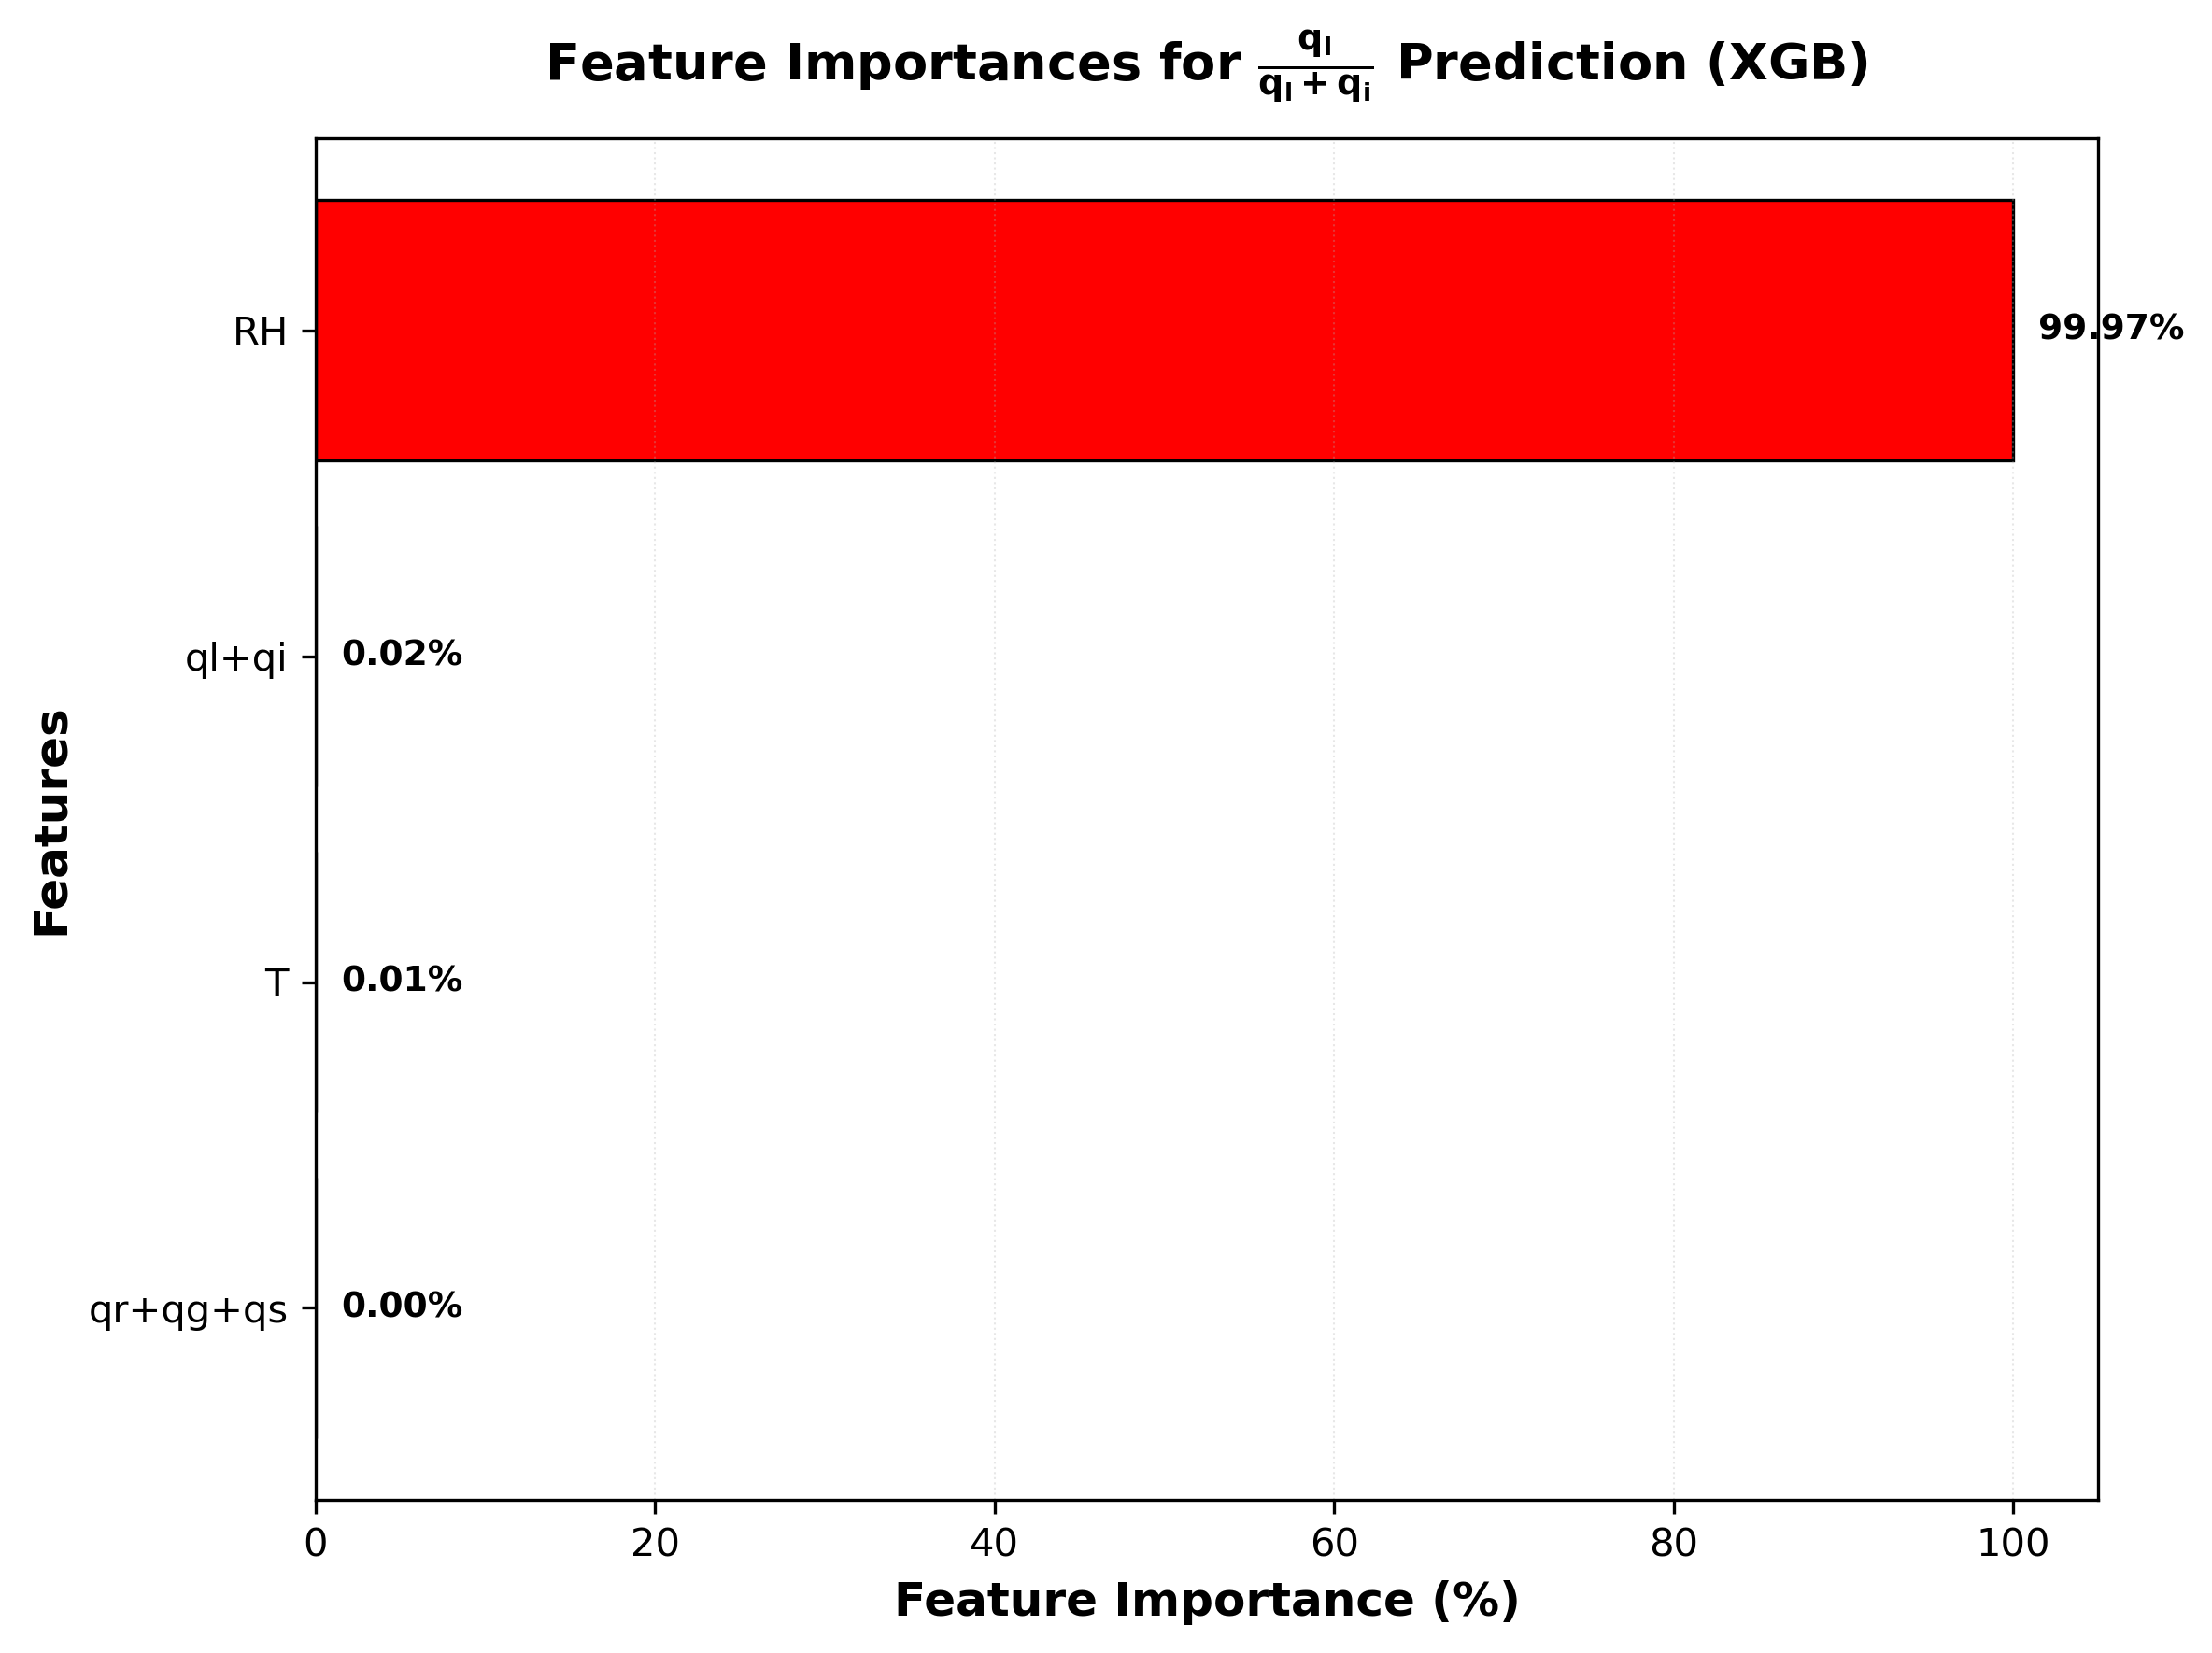

In [17]:
#Feature importance plot
importance = model.feature_importances_

#Combine feature names and scores
feature_scores = list(zip(feature_names, importance))

#Sort by score in descending order
feature_scores.sort(key=lambda x: x[1], reverse=True)

#Convert to percentages
names = []
importances = []

for name, score in feature_scores:
    pct = score * 100
    names.append(name)
    importances.append(pct)
    print(f"{name}: {pct:.4f} %")

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

bars = ax.barh(names, importances, color='red', edgecolor='black', linewidth=0.8)


ax.set_xlabel("Feature Importance (%)", fontsize=12, fontweight='bold')
ax.set_ylabel("Features", fontsize=12, fontweight='bold')
#ax.set_title(r"XGBoost Feature Importance: Ice-Phase Hydrometeor Fraction $\mathbf{\left(\frac{q_g}{q_s + q_g}\right)}$", 
ax.set_title(r"Feature Importances for $\mathbf{\frac{q_l}{q_l +q_i}}$ Prediction (XGB)", 
            fontsize=13, fontweight='bold', pad=15)

ax.invert_yaxis() #Highest importance at the top

#Add percentage values on bars
for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    ax.text(
        width + 1.5,
        y,
        f"{width:.2f}%",
        va="center",
        fontsize=9,
        fontweight='bold'
    )
ax.set_xlim(0, 105)

ax.grid(True, axis='x', alpha=0.3, linestyle=':', linewidth=0.5, zorder=0)

plt.tight_layout()
plt.savefig(f"../output/{output_folder_name}/FeatureImportance.png",
    dpi=300, bbox_inches='tight')

plt.show()


In [19]:
overall_end_time = time.time()
overall_elapsed_time = overall_end_time - overall_start_time
print(f"Overall Elapsed time: {overall_elapsed_time/60:.4f} minutes")

Overall Elapsed time: 8.7286 minutes
